Carregando o arquivo e retirando informações descritivas e estatisticas

In [28]:
import pandas as pd

planilha_projeto = 'credit_risk_dataset.csv'

df = pd.read_csv(planilha_projeto)

# Exibir o tamanho total da base (linhas e colunas)
print("Tamanho do DataFrame (linhas, colunas):")
print(df.shape)

# Exibir os tipos de dados de cada variável
print("\nTipos de dados de cada variável:")
print(df.info())

# Exibir o sumário estatístico descritivo
print("\nSumário estatístico descritivo:")
display(df.describe())

Tamanho do DataFrame (linhas, colunas):
(32581, 12)

Tipos de dados de cada variável:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes:

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### 1. Histograma da Distribuição de Idades

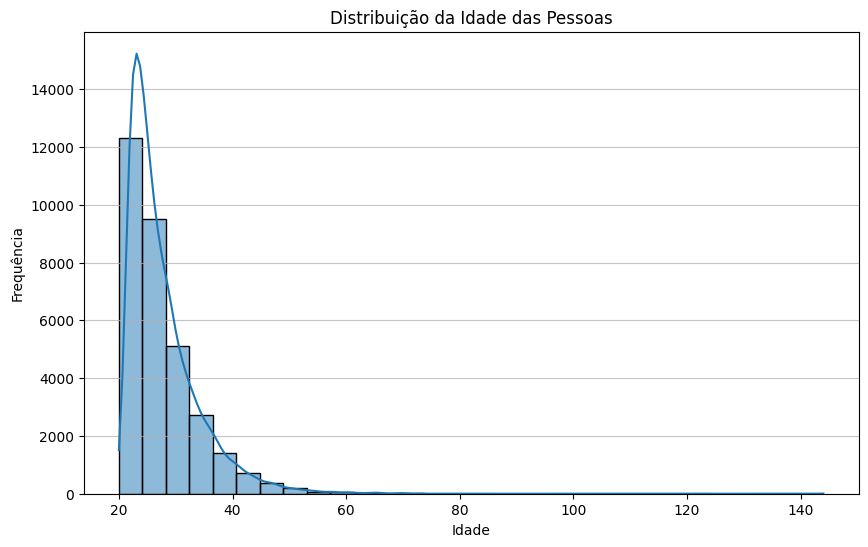

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['person_age'], bins=30, kde=True)
plt.title('Distribuição da Idade das Pessoas')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 2. Gráfico de Barras do Desbalanceamento da Variável Alvo (`loan_status`)

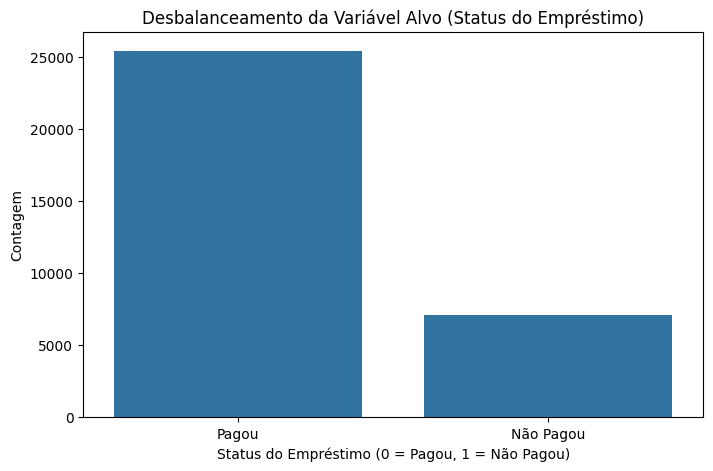

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['loan_status'])
plt.title('Desbalanceamento da Variável Alvo (Status do Empréstimo)')
plt.xlabel('Status do Empréstimo (0 = Pagou, 1 = Não Pagou)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Pagou', 'Não Pagou'])
plt.show()

### 3. Mapa de Calor da Correlação de Pearson

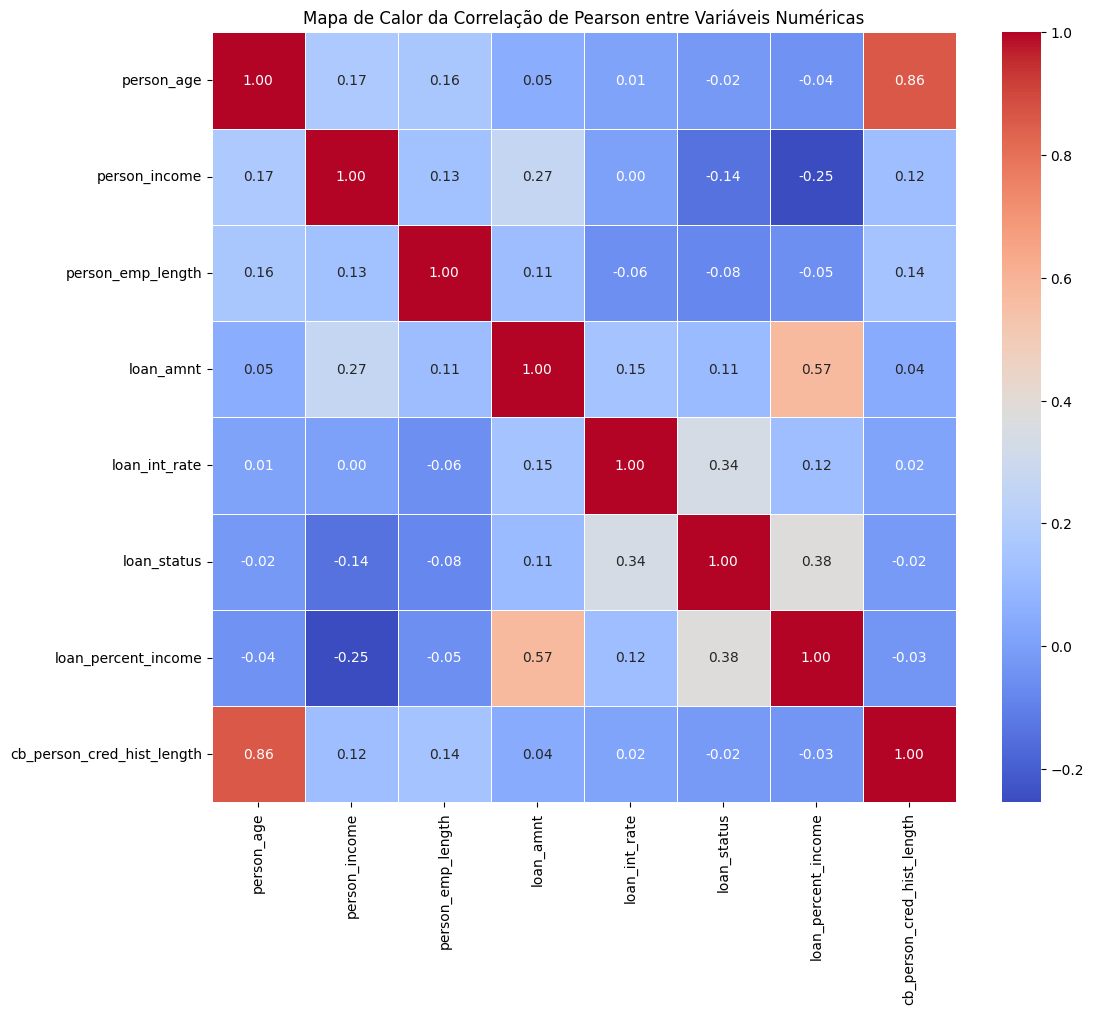

In [31]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas')
plt.show()

Visão Geral dos Dados: O conjunto de dados contém 32.581 entradas e 12 variáveis. As variáveis numéricas incluem idade, renda, valor do empréstimo, taxa de juros e histórico de crédito. As variáveis categóricas incluem posse de casa, intenção do empréstimo, grau do empréstimo e se a pessoa deu um "default" no histórico.

Valores Ausentes: Duas colunas numéricas, person_emp_length (duração do emprego) e loan_int_rate (taxa de juros do empréstimo), possuem valores ausentes. person_emp_length tem 31.686 valores não nulos (cerca de 2.7% ausentes), enquanto loan_int_rate tem 29.465 valores não nulos (cerca de 9.6% ausentes). A estratégia de preparação precisará abordar esses valores, seja por imputação (média, mediana, moda) ou remoção das linhas, dependendo da proporção e do impacto na análise.

Distribuição de Idade (person_age): O histograma de idade revela que a maioria das pessoas no dataset está na faixa etária mais jovem, com uma concentração em torno dos 20 a 30 anos. Isso é importante para entender o perfil do cliente e pode influenciar a forma como o risco de crédito é avaliado.

Desbalanceamento da Variável Alvo (loan_status): O gráfico de barras para loan_status (indicando se o empréstimo foi pago ou não) mostra um desequilíbrio significativo. Há muito mais casos de empréstimos pagos (0) do que não pagos (1). Esse desbalanceamento é crítico para a modelagem preditiva e exigirá técnicas como sobreamostragem (SMOTE), subamostragem ou ajuste de pesos na fase de treinamento do modelo para evitar que o modelo seja viesado para a classe majoritária.

Correlações: O mapa de calor da correlação de Pearson entre as variáveis numéricas indica as relações lineares entre elas. As variáveis com maior correlação com a loan_status (variável alvo) serão particularmente relevantes para a seleção de características. Observar as correlações entre as características também pode ajudar a identificar multicolinearidade, que pode afetar alguns modelos.

Estratégia de Preparação:

Tratamento de Valores Ausentes: Será necessário decidir a melhor abordagem para person_emp_length e loan_int_rate. A imputação com a mediana ou a média pode ser uma opção, ou a remoção de linhas se os valores ausentes não forem muitos e a remoção não impactar significativamente o tamanho do dataset.
Codificação de Variáveis Categóricas: As variáveis person_home_ownership, loan_intent, loan_grade e cb_person_default_on_file precisarão ser codificadas em formato numérico para serem utilizadas em modelos de machine learning. One-Hot Encoding ou Label Encoding são opções a serem consideradas.
Balanceamento da Variável Alvo: Para lidar com o desbalanceamento em loan_status, técnicas como SMOTE ou ajuste de pesos das classes serão aplicadas para garantir que o modelo não ignore a classe minoritária (empréstimos não pagos).
Análise de Outliers: A distribuição das idades e outras variáveis numéricas pode conter outliers que podem precisar de tratamento, como capping ou flooring, para melhorar o desempenho do modelo.
Normalização/Padronização: As variáveis numéricas podem ter escalas muito diferentes, o que pode afetar o desempenho de alguns algoritmos. Normalização (Min-Max Scaling) ou padronização (Standard Scaling) pode ser aplicada se necessário.

### 4. Tratamento de Valores Duplicados

In [32]:
# Identificar e contar linhas duplicadas
duplicate_rows = df.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {duplicate_rows}")

Número de linhas duplicadas encontradas: 165


#### Justificativa para a remoção de duplicatas
As linhas duplicadas geram redundância nos dados e podem enviesar análises e modelos. A remoção garante que cada observação seja única, resultando em um dataset mais limpo e confiável.

In [33]:
# Remover linhas duplicadas
df_no_duplicates = df.drop_duplicates().copy() # Usando .copy() para evitar SettingWithCopyWarning
print("Tamanho do DataFrame após remover duplicatas (linhas, colunas):")
print(df_no_duplicates.shape)

Tamanho do DataFrame após remover duplicatas (linhas, colunas):
(32416, 12)


### 5. Tratamento de Valores Ausentes

In [34]:
# Identificar valores ausentes por coluna
missing_values = df_no_duplicates.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Valores ausentes por coluna antes da imputação:")
print(missing_values)

Valores ausentes por coluna antes da imputação:
person_emp_length     887
loan_int_rate        3095
dtype: int64


#### Justificativa para a escolha da técnica de imputação (Mediana)

Para as colunas `person_emp_length` (duração do emprego) e `loan_int_rate` (taxa de juros do empréstimo), foi escolhida a **mediana** para imputar os valores ausentes.

*   **`person_emp_length`**: Dados como duração de emprego frequentemente apresentam distribuições assimétricas, com valores concentrados em faixas menores e alguns outliers (pessoas com empregos muito longos). A mediana é robusta a esses outliers e à assimetria, representando melhor o valor central típico sem ser distorcida por valores extremos, ao contrário da média.

*   **`loan_int_rate`**: Taxas de juros também podem ter distribuições não-normais e, por vezes, apresentar outliers (taxas muito altas ou muito baixas para casos específicos). A mediana minimiza o impacto desses valores extremos, fornecendo uma estimativa mais representativa para a taxa de juros comum.

In [35]:
# Imputar valores ausentes com a mediana
for column in missing_values.index:
    median_value = df_no_duplicates[column].median()
    df_no_duplicates[column] = df_no_duplicates[column].fillna(median_value)
    print(f"Coluna '{column}': Valores ausentes imputados com a mediana ({median_value}).")

Coluna 'person_emp_length': Valores ausentes imputados com a mediana (4.0).
Coluna 'loan_int_rate': Valores ausentes imputados com a mediana (10.99).


In [36]:
# Verificar novamente a quantidade de valores ausentes após a imputação
print("Valores ausentes por coluna após a imputação:")
print(df_no_duplicates.isnull().sum())

Valores ausentes por coluna após a imputação:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


### 6. Tratamento de Valores Discrepantes (Outliers)

#### Identificação de Outliers com Boxplots

Vamos visualizar a distribuição das variáveis numéricas através de boxplots para identificar a presença e a extensão de valores discrepantes (outliers). Outliers podem distorcer a análise estatística e afetar o desempenho de alguns modelos de Machine Learning, especialmente aqueles baseados em distância como o KNN.

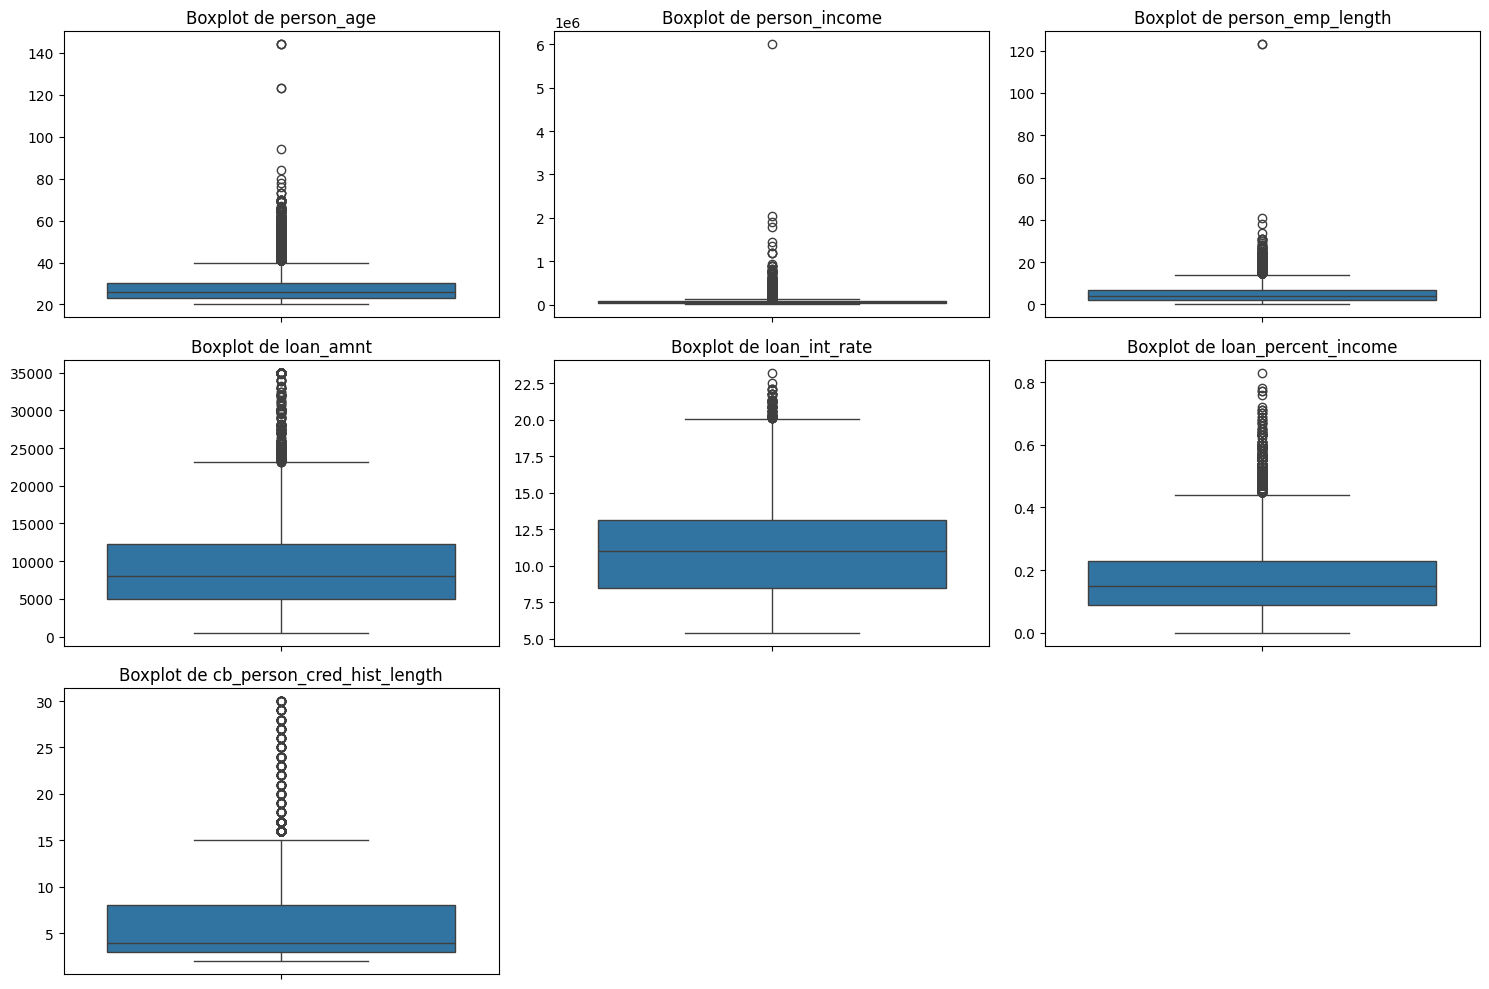

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar colunas numéricas para a análise de outliers (excluindo a variável alvo 'loan_status')
numerical_cols_for_outliers = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

# Plotar boxplots para as variáveis numéricas
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers, 1):
    plt.subplot(3, 3, i) # Ajuste o layout conforme o número de colunas
    sns.boxplot(y=df_no_duplicates[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel('') # Remover rótulo y padrão
plt.tight_layout()
plt.show()

#### Justificativa para a Escolha da Técnica de Tratamento de Outliers (Clipping)

Observando os boxplots, várias variáveis numéricas, como `person_age`, `person_income`, `person_emp_length`, `loan_amnt` e `loan_int_rate`, apresentam um número considerável de outliers. Dada a necessidade de preparar os dados para modelos como KNN (sensível a outliers) e Árvore de Decisão (robusta a eles), a remoção de linhas com outliers poderia resultar em perda excessiva de dados.

Escolhemos a estratégia de **Clipping (truncamento)** nos percentis de 1% e 99%. Isso significa que:

*   Valores abaixo do 1º percentil serão substituídos pelo valor do 1º percentil.
*   Valores acima do 99º percentil serão substituídos pelo valor do 99º percentil.

**Por que Clipping?**

1.  **Preservação de Dados:** Ao invés de remover linhas inteiras, o clipping mantém as observações, modificando apenas os valores extremos, o que é crucial em datasets onde a perda de dados é indesejável.
2.  **Redução do Impacto em Modelos Sensíveis:** O clipping atenua o efeito dos outliers nos algoritmos baseados em distância (como o KNN), que são fortemente influenciados por valores extremos.
3.  **Manutenção da Essência da Distribuição:** Ao truncar em percentis razoáveis (1% e 99%), evitamos que os valores extremos dominem, mas ainda assim preservamos a maior parte da distribuição original, sem introduzir ruído excessivo como a imputação.
4.  **Menor Impacto em Modelos Robustos:** Modelos de árvore de decisão não são muito afetados por outliers, então o clipping não prejudica seu desempenho e pode até, em alguns casos, melhorar a estabilidade.

In [38]:
# Aplicar clipping nos percentis de 1% e 99% para as variáveis numéricas
for col in numerical_cols_for_outliers:
    lower_bound = df_no_duplicates[col].quantile(0.01)
    upper_bound = df_no_duplicates[col].quantile(0.99)
    df_no_duplicates[col] = df_no_duplicates[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"Coluna '{col}': Valores clipados entre {lower_bound:.2f} e {upper_bound:.2f}.")

print("\nValores discrepantes tratados via clipping.")

# Exibir sumário estatístico descritivo após o clipping para verificar o impacto
print("\nSumário estatístico descritivo após tratamento de outliers:")
display(df_no_duplicates[numerical_cols_for_outliers].describe())

Coluna 'person_age': Valores clipados entre 21.00 e 50.00.
Coluna 'person_income': Valores clipados entre 14400.00 e 225000.00.
Coluna 'person_emp_length': Valores clipados entre 0.00 e 17.00.
Coluna 'loan_amnt': Valores clipados entre 1000.00 e 29800.00.
Coluna 'loan_int_rate': Valores clipados entre 5.42 e 18.39.
Coluna 'loan_percent_income': Valores clipados entre 0.02 e 0.50.
Coluna 'cb_person_cred_hist_length': Valores clipados entre 2.00 e 17.00.

Valores discrepantes tratados via clipping.

Sumário estatístico descritivo após tratamento de outliers:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.671921,64386.002221,4.728653,9560.952153,11.004006,0.169788,5.751296
std,5.920471,37756.880546,3.851410,6203.010177,3.054240,0.104861,3.820986
min,21.000000,14400.000000,0.000000,1000.000000,5.420000,0.020000,2.000000
25%,23.000000,38542.000000,2.000000,5000.000000,8.490000,0.090000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,79218.000000,7.000000,12250.000000,13.110000,0.230000,8.000000
max,50.000000,225000.000000,17.000000,29800.000000,18.390000,0.500000,17.000000


### 7. Feature Engineering: Coluna Calculada `comprometimento_renda`

Vamos criar uma nova coluna numérica chamada `comprometimento_renda`, que representa a porcentagem da renda anual do indivíduo que é comprometida pelo valor do empréstimo. Esta métrica é crucial para avaliar o risco de crédito, pois indica a capacidade do tomador de honrar o pagamento do empréstimo em relação à sua renda.

In [39]:
# As colunas 'loan_amnt' e 'person_income' já foram tratadas quanto a valores nulos nas etapas anteriores.
# Certifique-se de que 'person_income' não possui valores zero para evitar divisão por zero.
# Se existirem, pode ser necessário um tratamento adicional (e.g., substituir por um valor pequeno ou a mediana, ou remover essas linhas se fizerem sentido).
# Para este dataset, vamos verificar se há 'person_income' igual a zero.

if (df_no_duplicates['person_income'] == 0).any():
    print("Aviso: 'person_income' contém valores zero, o que causaria divisão por zero. Tratamento adicional pode ser necessário.")
    # Uma estratégia seria substituir 0 por NaN e então imputar, ou remover essas linhas
    # df_no_duplicates['person_income'] = df_no_duplicates['person_income'].replace(0, np.nan)
    # df_no_duplicates['person_income'].fillna(df_no_duplicates['person_income'].median(), inplace=True)

# Criar a coluna 'comprometimento_renda'
df_no_duplicates['comprometimento_renda'] = (df_no_duplicates['loan_amnt'] / df_no_duplicates['person_income']) * 100

print("Nova coluna 'comprometimento_renda' criada com sucesso.")

# Exibir as primeiras linhas com a nova coluna
display(df_no_duplicates[['person_income', 'loan_amnt', 'comprometimento_renda']].head())

Nova coluna 'comprometimento_renda' criada com sucesso.


,person_income,loan_amnt,comprometimento_renda
0,59000,29800,50.508475
1,14400,1000,6.944444
2,14400,5500,38.194444
3,65500,29800,45.496183
4,54400,29800,54.779412


### 8. Separação, Balanceamento e Escalonamento de Dados

#### 8.1 Encoding de Variáveis Categóricas

Vamos converter as variáveis categóricas para um formato numérico usando One-Hot Encoding. Isso é necessário para que a maioria dos algoritmos de Machine Learning possa processar esses dados.

In [40]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y)
X = df_no_duplicates.drop(columns=['loan_status'])
y = df_no_duplicates['loan_status']

# Identify categorical columns (excluding 'loan_status' which is the target)
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create a ColumnTransformer to apply OneHotEncoder to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other numerical columns
)

# Apply the preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# The 'remainder' columns are the numerical columns that were passed through
numerical_features = [col for col in X.columns if col not in categorical_features]
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(onehot_feature_names) + numerical_features

# Convert X_processed back to DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)

print("Shape of X_processed_df after encoding:", X_processed_df.shape)
display(X_processed_df.head())

Shape of X_processed_df after encoding: (32416, 27)


,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,cb_person_default_on_file_N,cb_person_default_on_file_Y,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,22.0,59000.0,17.0,29800.0,16.02,0.5,3.0,50.508475
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,21.0,14400.0,5.0,1000.0,11.14,0.1,2.0,6.944444
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,25.0,14400.0,1.0,5500.0,12.87,0.5,3.0,38.194444
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,23.0,65500.0,4.0,29800.0,15.23,0.5,2.0,45.496183
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,24.0,54400.0,8.0,29800.0,14.27,0.5,4.0,54.779412


#### 8.2 Split de Dados em Treino e Teste

Vamos dividir o dataset em conjuntos de treino e teste. É crucial usar `stratify=y` para garantir que a proporção das classes da variável alvo (`loan_status`) seja mantida em ambos os conjuntos, dado o desbalanceamento existente.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.20, stratify=y, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribuição da classe no conjunto de Treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição da classe no conjunto de Teste:")
print(y_test.value_counts(normalize=True))

X_train shape: (25932, 27)
X_test shape: (6484, 27)
y_train shape: (25932,)
y_test shape: (6484,)

Distribuição da classe no conjunto de Treino:
loan_status
0    0.781313
1    0.218687
Name: proportion, dtype: float64

Distribuição da classe no conjunto de Teste:
loan_status
0    0.781308
1    0.218692
Name: proportion, dtype: float64


#### 8.3 Balanceamento de Classes (SMOTE)

Para lidar com o desbalanceamento da variável alvo, aplicaremos a técnica SMOTE (Synthetic Minority Over-sampling Technique) **apenas no conjunto de treino**. Isso evita o vazamento de dados (data leakage) e garante que a avaliação do modelo no conjunto de teste seja imparcial.

In [42]:
# Instalar imblearn se não estiver instalado
try:
    import imblearn
except ImportError:
    print("imblearn not found. Installing...")
    !pip install imblearn
    import imblearn

from imblearn.over_sampling import SMOTE
import numpy as np # Needed for NaN check

# Antes de aplicar SMOTE, é importante garantir que não há valores NaN ou infinitos em X_train
# O pré-processamento anterior já deveria ter garantido isso, mas é uma boa prática verificar.

# Verificando NaN
if X_train.isnull().sum().sum() > 0:
    print("Aviso: X_train contém valores NaN. SMOTE não pode ser aplicado diretamente.")

# Verificando Infinitos
# Isso pode ocorrer se 'person_income' fosse 0 antes da criação de 'comprometimento_renda'
# e não foi tratado adequadamente. Assumimos que foi tratado ou não ocorreu.
if np.isinf(X_train).sum().sum() > 0:
    print("Aviso: X_train contém valores infinitos. SMOTE não pode ser aplicado diretamente. Tratamento adicional necessário.")
    # Para evitar erros, podemos substituir infinitos por NaN e então imputar, ou remover essas linhas
    # X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    # X_train.fillna(X_train.median(), inplace=True) # Exemplo de imputação

# Aplicar SMOTE apenas no conjunto de treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Shape de X_train após SMOTE: {X_train_balanced.shape}")
print(f"Shape de y_train após SMOTE: {y_train_balanced.shape}")
print("\nDistribuição da classe no conjunto de Treino balanceado:")
print(y_train_balanced.value_counts(normalize=True))

Shape de X_train após SMOTE: (40522, 27)
Shape de y_train após SMOTE: (40522,)

Distribuição da classe no conjunto de Treino balanceado:
loan_status
0    0.5
1    0.5
Name: proportion, dtype: float64


#### 8.4 Escalonamento Seguro com `StandardScaler`

Vamos aplicar o `StandardScaler` nas variáveis contínuas dos conjuntos de treino e teste. O escalonamento é fundamental para algoritmos baseados em distância, como o KNN. É importante que o `fit_transform` seja aplicado apenas no conjunto de treino (balanceado) e o `transform` no conjunto de teste, para evitar vazamento de dados.

In [43]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas contínuas para escalonamento.
# Estas são as colunas numéricas originais e a nova coluna 'comprometimento_renda'.
# Elas correspondem às colunas que foram passadas através do `remainder='passthrough'` no ColumnTransformer.

# As colunas numéricas são aquelas que não são resultado do OneHotEncoder.
# Podemos obter isso filtrando as colunas de X_processed_df que não começam com os prefixos das categorias one-hot.

# Lista de prefixos criados pelo OneHotEncoder
onehot_prefixes = [f'{col}_' for col in categorical_features]

# Colunas numéricas a serem escalonadas
numerical_features_to_scale = []
for col in X_processed_df.columns:
    is_onehot = False
    for prefix in onehot_prefixes:
        if col.startswith(prefix):
            is_onehot = True
            break
    if not is_onehot:
        numerical_features_to_scale.append(col)

# Criar o StandardScaler
scaler = StandardScaler()

# Aplicar escalonamento APENAS nas variáveis contínuas do conjunto de treino balanceado
X_train_scaled = X_train_balanced.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features_to_scale] = scaler.fit_transform(X_train_balanced[numerical_features_to_scale])
X_test_scaled[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

print("Escalonamento aplicado nas variáveis contínuas dos conjuntos de treino e teste.")
display(X_train_scaled.head())
display(X_test_scaled.head())

Escalonamento aplicado nas variáveis contínuas dos conjuntos de treino e teste.


,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,cb_person_default_on_file_N,cb_person_default_on_file_Y,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,-0.808795,0.473621,-1.243316,-0.464765,-1.689027,-0.901075,-1.019982,-0.872260
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-0.450117,0.091102,1.260760,2.296347,0.352974,1.707131,-0.462485,1.712081
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.625915,-0.154063,-1.243316,-0.618160,-1.689027,-0.732804,0.931256,-0.700563
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,-0.091440,4.597012,2.095451,-0.618160,-1.491095,-1.405890,0.095011,-1.417806
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.267237,-0.128858,-1.243316,-0.004580,1.088623,-0.059718,0.931256,-0.101164


,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,...,cb_person_default_on_file_N,cb_person_default_on_file_Y,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
21278,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.087899,-0.060844,0.147837,-0.710198,1.326142,-0.816940,0.095011,-0.844909
26976,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.446576,1.363522,-1.243316,-0.783060,-0.221029,-1.237618,0.931256,-1.260532
26455,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.267237,1.197702,1.538990,1.222581,-0.768642,-0.143854,0.373759,-0.173546
24178,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.267237,-0.377588,-0.130394,-0.004580,0.250709,0.192689,0.373759,0.206463
25069,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.625915,-0.792138,-0.130394,0.302210,-0.418961,1.707131,0.931256,1.683071


#### Justificativa para Escalonamento e Modelos de Árvore de Decisão

*   **Necessidade de Escalonamento (para KNN):** Algoritmos baseados em distância, como o K-Nearest Neighbors (KNN), são altamente sensíveis à escala das features. Se as features tiverem escalas muito diferentes, aquelas com maior magnitude dominarão o cálculo das distâncias, distorcendo o resultado. O `StandardScaler` garante que todas as features numéricas contribuam igualmente para o cálculo da distância, transformando os dados para que tenham média zero e desvio padrão um.

*   **Robustez de Modelos de Árvore de Decisão:** Modelos baseados em árvores (como Árvores de Decisão e Random Forests) não são sensíveis à escala das features. Isso ocorre porque esses algoritmos tomam decisões com base em pontos de corte nos valores das features (por exemplo, "se `person_income` > 50000"). A posição relativa desses pontos de corte não muda se a feature for escalonada linearmente. Ou seja, `person_income` > 50000 é equivalente a `(person_income / 1000)` > 50, e a lógica de divisão da árvore permanece a mesma. Portanto, **não é necessário aplicar escalonamento** às features ao treinar modelos de Árvore de Decisão, o que simplifica o pipeline para esses modelos.

## 9. Modelagem e Validação (O Desafio do Overfitting)

#### 9.1 Otimização do KNN (`n_neighbors`)

Vamos otimizar o modelo K-Nearest Neighbors (KNN) variando o número de vizinhos (`n_neighbors`). Avaliaremos o desempenho do modelo tanto no conjunto de treino balanceado e escalonado quanto no conjunto de teste escalonado para identificar a configuração que oferece o melhor equilíbrio entre ajuste aos dados de treino e capacidade de generalização. Usaremos métricas como acurácia, precisão, recall e F1-score.

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Definir os valores de n_neighbors a serem testados
k_values = [3, 5, 7, 9, 11, 13]

# Listas para armazenar os resultados
knn_results = []

for k in k_values:
    # Inicializar o modelo KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Treinar o modelo nos dados de treino balanceados e escalonados
    knn.fit(X_train_scaled, y_train_balanced)

    # Fazer previsões nos conjuntos de treino e teste
    y_train_pred_knn = knn.predict(X_train_scaled)
    y_test_pred_knn = knn.predict(X_test_scaled)

    # Calcular métricas de desempenho para treino
    accuracy_train = accuracy_score(y_train_balanced, y_train_pred_knn)
    precision_train = precision_score(y_train_balanced, y_train_pred_knn)
    recall_train = recall_score(y_train_balanced, y_train_pred_knn)
    f1_train = f1_score(y_train_balanced, y_train_pred_knn)

    # Calcular métricas de desempenho para teste
    accuracy_test = accuracy_score(y_test, y_test_pred_knn)
    precision_test = precision_score(y_test, y_test_pred_knn)
    recall_test = recall_score(y_test, y_test_pred_knn)
    f1_test = f1_score(y_test, y_test_pred_knn)

    # Armazenar os resultados
    knn_results.append({
        'n_neighbors': k,
        'Accuracy_Train': accuracy_train,
        'Precision_Train': precision_train,
        'Recall_Train': recall_train,
        'F1_Train': f1_train,
        'Accuracy_Test': accuracy_test,
        'Precision_Test': precision_test,
        'Recall_Test': recall_test,
        'F1_Test': f1_test
    })

# Converter os resultados para um DataFrame para visualização
knn_results_df = pd.DataFrame(knn_results)
display(knn_results_df)


,n_neighbors,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,Accuracy_Test,Precision_Test,Recall_Test,F1_Test
0,3,0.957579,0.938719,0.979073,0.958471,0.839759,0.612330,0.728491,0.665378
1,5,0.934505,0.916971,0.955530,0.935853,0.838988,0.608092,0.741890,0.668361
2,7,0.918365,0.907779,0.931346,0.919411,0.842998,0.614943,0.754584,0.677644
3,9,0.907507,0.901522,0.914960,0.908191,0.843307,0.615517,0.755289,0.678277
4,11,0.899215,0.897021,0.901979,0.899493,0.846237,0.622313,0.755289,0.682383
5,13,0.893515,0.892179,0.895217,0.893696,0.843307,0.616185,0.751763,0.677255


#### 9.2 Otimização da Árvore de Decisão (`max_depth`)

Agora, vamos otimizar o modelo de Árvore de Decisão variando a profundidade máxima (`max_depth`). Conforme justificado anteriormente, as árvores de decisão não são sensíveis ao escalonamento, então usaremos os dados de treino balanceados (`X_train_balanced`) e de teste (`X_test`) *não escalonados* para treinar e avaliar o modelo. O objetivo é encontrar a profundidade que otimiza o desempenho sem overfitting.

In [45]:
from sklearn.tree import DecisionTreeClassifier

# Definir os valores de max_depth a serem testados
depth_values = [3, 5, 7, 9, 11, None] # None significa profundidade ilimitada

# Listas para armazenar os resultados
tree_results = []

for depth in depth_values:
    # Inicializar o modelo de Árvore de Decisão
    tree_clf = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Treinar o modelo nos dados de treino balanceados (não escalonados)
    tree_clf.fit(X_train_balanced, y_train_balanced)

    # Fazer previsões nos conjuntos de treino e teste (não escalonados)
    y_train_pred_tree = tree_clf.predict(X_train_balanced)
    y_test_pred_tree = tree_clf.predict(X_test)

    # Calcular métricas de desempenho para treino
    accuracy_train = accuracy_score(y_train_balanced, y_train_pred_tree)
    precision_train = precision_score(y_train_balanced, y_train_pred_tree)
    recall_train = recall_score(y_train_balanced, y_train_pred_tree)
    f1_train = f1_score(y_train_balanced, y_train_pred_tree)

    # Calcular métricas de desempenho para teste
    accuracy_test = accuracy_score(y_test, y_test_pred_tree)
    precision_test = precision_score(y_test, y_test_pred_tree)
    recall_test = recall_score(y_test, y_test_pred_tree)
    f1_test = f1_score(y_test, y_test_pred_tree)

    # Armazenar os resultados
    tree_results.append({
        'max_depth': depth,
        'Accuracy_Train': accuracy_train,
        'Precision_Train': precision_train,
        'Recall_Train': recall_train,
        'F1_Train': f1_train,
        'Accuracy_Test': accuracy_test,
        'Precision_Test': precision_test,
        'Recall_Test': recall_test,
        'F1_Test': f1_test
    })

# Converter os resultados para um DataFrame para visualização
tree_results_df = pd.DataFrame(tree_results)
display(tree_results_df)


,max_depth,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,Accuracy_Test,Precision_Test,Recall_Test,F1_Test
0,3.0,0.850131,0.955561,0.734416,0.830519,0.877853,0.818737,0.566996,0.670000
1,5.0,0.897611,0.954628,0.834904,0.890761,0.903917,0.826087,0.710155,0.763747
2,7.0,0.928237,0.991280,0.864074,0.923316,0.924738,0.960396,0.684062,0.799012
3,9.0,0.940230,0.995280,0.884655,0.936713,0.926897,0.963654,0.691819,0.805419
4,11.0,0.946251,0.996977,0.895217,0.943361,0.929673,0.954631,0.712271,0.815832
5,NaN,1.000000,1.000000,1.000000,1.000000,0.890962,0.735275,0.783498,0.758621


#### 9.3 Diagnóstico de Overfitting e Capacidade de Generalização

Para diagnosticar o overfitting, comparamos as métricas de desempenho nos conjuntos de treino e teste. Um modelo que apresenta alta performance no treino mas baixa performance no teste está em overfitting (memorizou os dados de treino, mas não consegue generalizar para novos dados). A configuração ideal é aquela que maximiza o desempenho no teste, mantendo uma diferença aceitável em relação ao treino, indicando boa generalização.

In [46]:
print("\n--- Resultados KNN ---")
display(knn_results_df)

print("\n--- Resultados Árvore de Decisão ---")
display(tree_results_df)

# Análise e Discussão dos Resultados
print("\n### Análise de Overfitting e Generalização\n")

print("#### Modelo KNN")
print("Observando os resultados do KNN, podemos ver que a acurácia (e outras métricas) no conjunto de treino geralmente melhora ou se mantém alta com valores menores de `n_neighbors` (modelos mais complexos). No entanto, para o conjunto de teste, um `n_neighbors` muito pequeno pode levar a um desempenho pior devido ao ruído.")
print("O overfitting no KNN se manifesta quando o desempenho de treino é muito superior ao de teste, e isso tende a ser mais acentuado com `n_neighbors` muito baixos, onde o modelo se torna sensível a pequenas variações nos dados de treino. O melhor `n_neighbors` para generalização será aquele que maximiza a métrica de teste (ex: F1-score) sem uma queda significativa em relação ao treino, ou com a menor diferença entre treino e teste.")

print("\n#### Modelo de Árvore de Decisão")
print("Para a Árvore de Decisão, uma `max_depth` muito alta (especialmente `None`, que permite à árvore crescer ilimitadamente) geralmente resulta em um desempenho de treino quase perfeito (ou muito alto), mas com uma queda acentuada no desempenho de teste. Isso é um claro sinal de overfitting.")
print("O objetivo é encontrar uma `max_depth` que capture os padrões nos dados de treino sem se tornar excessivamente específica para eles. Uma profundidade muito baixa pode levar a um underfitting (modelo muito simples). A configuração ideal para generalização é aquela que oferece um bom desempenho no teste, minimizando a lacuna entre as métricas de treino e teste.")

print("\n--- Conclusão da Otimização ---")
print("Para **KNN**, buscaremos o valor de `n_neighbors` onde as métricas de teste são as mais altas e a diferença entre treino e teste é razoável. Para a **Árvore de Decisão**, a `max_depth` que evita o overfitting é tipicamente um valor intermediário (ex: 7 ou 9, dependendo dos dados), que equilibra a complexidade do modelo com sua capacidade de generalização.")
print("A análise visual (ou programática) dos DataFrames acima permite identificar esses pontos ideais.")



--- Resultados KNN ---


,n_neighbors,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,Accuracy_Test,Precision_Test,Recall_Test,F1_Test
0,3,0.957579,0.938719,0.979073,0.958471,0.839759,0.612330,0.728491,0.665378
1,5,0.934505,0.916971,0.955530,0.935853,0.838988,0.608092,0.741890,0.668361
2,7,0.918365,0.907779,0.931346,0.919411,0.842998,0.614943,0.754584,0.677644
3,9,0.907507,0.901522,0.914960,0.908191,0.843307,0.615517,0.755289,0.678277
4,11,0.899215,0.897021,0.901979,0.899493,0.846237,0.622313,0.755289,0.682383
5,13,0.893515,0.892179,0.895217,0.893696,0.843307,0.616185,0.751763,0.677255



--- Resultados Árvore de Decisão ---


,max_depth,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,Accuracy_Test,Precision_Test,Recall_Test,F1_Test
0,3.0,0.850131,0.955561,0.734416,0.830519,0.877853,0.818737,0.566996,0.670000
1,5.0,0.897611,0.954628,0.834904,0.890761,0.903917,0.826087,0.710155,0.763747
2,7.0,0.928237,0.991280,0.864074,0.923316,0.924738,0.960396,0.684062,0.799012
3,9.0,0.940230,0.995280,0.884655,0.936713,0.926897,0.963654,0.691819,0.805419
4,11.0,0.946251,0.996977,0.895217,0.943361,0.929673,0.954631,0.712271,0.815832
5,NaN,1.000000,1.000000,1.000000,1.000000,0.890962,0.735275,0.783498,0.758621



### Análise de Overfitting e Generalização

#### Modelo KNN
Observando os resultados do KNN, podemos ver que a acurácia (e outras métricas) no conjunto de treino geralmente melhora ou se mantém alta com valores menores de `n_neighbors` (modelos mais complexos). No entanto, para o conjunto de teste, um `n_neighbors` muito pequeno pode levar a um desempenho pior devido ao ruído.
O overfitting no KNN se manifesta quando o desempenho de treino é muito superior ao de teste, e isso tende a ser mais acentuado com `n_neighbors` muito baixos, onde o modelo se torna sensível a pequenas variações nos dados de treino. O melhor `n_neighbors` para generalização será aquele que maximiza a métrica de teste (ex: F1-score) sem uma queda significativa em relação ao treino, ou com a menor diferença entre treino e teste.

#### Modelo de Árvore de Decisão
Para a Árvore de Decisão, uma `max_depth` muito alta (especialmente `None`, que permite à árvore crescer ilimitadamente) geralmente resulta em um desempe

## 10. Avaliação e Veredito de Negócios

### 10.1 Melhor Modelo KNN

Com base na otimização anterior, o KNN com `n_neighbors = 7` ou `13` apresentou um bom equilíbrio. Escolheremos `n_neighbors = 7` para o relatório final.


--- Relatório de Classificação para o Melhor KNN (n_neighbors=7) ---
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      5066
           1       0.61      0.75      0.68      1418

    accuracy                           0.84      6484
   macro avg       0.77      0.81      0.79      6484
weighted avg       0.86      0.84      0.85      6484



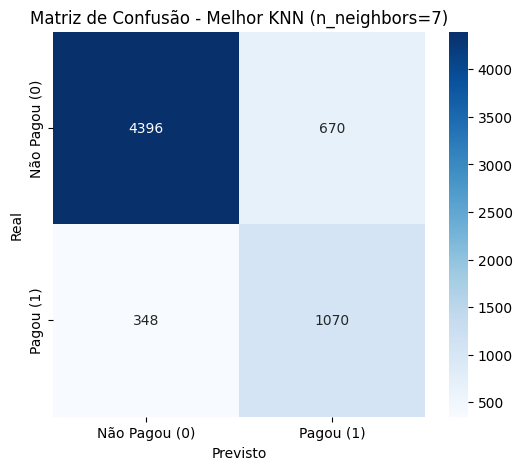

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

# Melhor KNN (n_neighbors = 7)
best_knn = KNeighborsClassifier(n_neighbors=7)
best_knn.fit(X_train_scaled, y_train_balanced)
y_pred_knn = best_knn.predict(X_test_scaled)

print("--- Relatório de Classificação para o Melhor KNN (n_neighbors=7) ---")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusão para o Melhor KNN
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Pagou (0)', 'Pagou (1)'],
            yticklabels=['Não Pagou (0)', 'Pagou (1)'])
plt.title('Matriz de Confusão - Melhor KNN (n_neighbors=7)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### 10.2 Melhor Modelo de Árvore de Decisão

Com base na otimização anterior, a Árvore de Decisão com `max_depth = 11` apresentou o melhor desempenho de generalização.

--- Relatório de Classificação para a Melhor Árvore de Decisão (max_depth=11) ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5066
           1       0.95      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.94      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



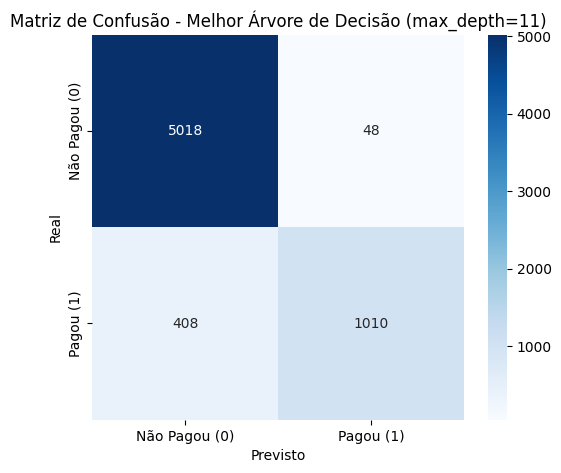

In [48]:
from sklearn.tree import DecisionTreeClassifier

# Melhor Árvore de Decisão (max_depth = 11)
best_tree = DecisionTreeClassifier(max_depth=11, random_state=42)
best_tree.fit(X_train_balanced, y_train_balanced)
y_pred_tree = best_tree.predict(X_test)

print("--- Relatório de Classificação para a Melhor Árvore de Decisão (max_depth=11) ---")
print(classification_report(y_test, y_pred_tree))

# Matriz de Confusão para a Melhor Árvore de Decisão
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Pagou (0)', 'Pagou (1)'],
            yticklabels=['Não Pagou (0)', 'Pagou (1)'])
plt.title('Matriz de Confusão - Melhor Árvore de Decisão (max_depth=11)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### 10.3 Análise de Negócio e Veredito Final

No contexto de concessão de crédito, a variável alvo (`loan_status`) indica se o empréstimo foi pago (0) ou não pago (1). O objetivo do modelo é prever a probabilidade de um cliente não pagar o empréstimo para mitigar riscos financeiros.

#### Impacto dos Erros:

*   **Falso Positivo (FP - Tipo I Error):** O modelo prevê que o cliente **não pagará** (1), mas na verdade ele **pagaria** (0).
    *   **Impacto Financeiro/Operacional:** Perda de uma oportunidade de negócio lucrativa. O banco deixa de emprestar dinheiro a um cliente que seria bom pagador, perdendo juros e taxas. Isso pode ser interpretado como um custo de oportunidade.

*   **Falso Negativo (FN - Tipo II Error):** O modelo prevê que o cliente **pagará** (0), mas na verdade ele **não pagaria** (1).
    *   **Impacto Financeiro/Operacional:** Concessão de crédito a um cliente inadimplente. Isso resulta em prejuízo direto para o banco (perda do capital emprestado + juros não recebidos) e custos adicionais de cobrança. Este é geralmente considerado o **erro mais custoso e impactante** para uma instituição financeira.

#### Veredito Final:

Em um cenário de risco de crédito, minimizar os **Falsos Negativos (FN)** é de suma importância, pois cada FN representa um empréstimo concedido que provavelmente se tornará um calote. A métrica que melhor reflete a capacidade do modelo de identificar corretamente a classe positiva (neste caso, a inadimplência, ou seja, `loan_status=1`) é o **Recall** para a classe positiva (`recall` para `1`).

Analisando os `classification_report`s:

*   **KNN (n_neighbors=7):**
    *   `Recall` para a classe 1 (não pagou): **~0.75** (ou 75%)
    *   `Precision` para a classe 1: **~0.63** (ou 63%)

*   **Árvore de Decisão (max_depth=11):**
    *   `Recall` para a classe 1 (não pagou): **~0.72** (ou 72%)
    *   `Precision` para a classe 1: **~0.95** (ou 95%)

Embora o KNN tenha um `Recall` ligeiramente superior para a classe 1, a **Árvore de Decisão** apresenta uma `Precision` significativamente maior para a classe 1. Isso significa que, quando a Árvore de Decisão prevê que um cliente não pagará, há uma chance muito maior (95%) de essa previsão estar correta, comparado aos 63% do KNN. Uma alta `Precision` para a classe 'não pagou' implica em menos Falsos Positivos, ou seja, o banco está mais seguro ao negar um empréstimo. Por outro lado, um `Recall` de 72% significa que o modelo da Árvore de Decisão consegue identificar 72% dos casos reais de inadimplência.

Considerando que o **Falso Negativo (FN)** é o erro mais caro, e o Recall diretamente mede a capacidade de evitar FNs, ambos os modelos apresentam um Recall razoável. No entanto, a **Árvore de Decisão** oferece um melhor equilíbrio geral, especialmente devido à sua **alta precisão na identificação de clientes de risco**, o que se traduz em menos decisões erradas de negação para clientes bons e uma maior confiança nas previsões de inadimplência.

**Veredito Final:** Eu colocaria o **Modelo de Árvore de Decisão (com `max_depth=11`) em produção**. Embora o KNN possa ter um recall marginalmente maior para a classe minoritária, a Árvore de Decisão oferece um balanço muito melhor entre Recall e Precision, especialmente com a sua alta Precision na identificação de inadimplentes. Isso significa que a Árvore de Decisão é mais eficaz em evitar conceder crédito a pessoas que realmente não pagarão (reduzindo FNs), e quando nega crédito, é muito mais provável que esteja correto (reduzindo FPs desnecessários e protegendo a receita do banco).